In [1]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bambi as bmb
import preliz as pz

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='pytensor')

In [3]:
SEED = 12

In [4]:
pizza = pd.read_csv('../data/pizza_sales.csv', index_col=0)

In [5]:
pizza = pizza.head(500).copy()

In [6]:
pizza['order_time'] = pd.to_datetime(pizza['order_time'], format='%H:%M:%S')

In [7]:
pizza['order_time_continuous'] = (
    pizza['order_time'].dt.hour +
    pizza['order_time'].dt.minute / 60 +
    pizza['order_time'].dt.second / 3600
)

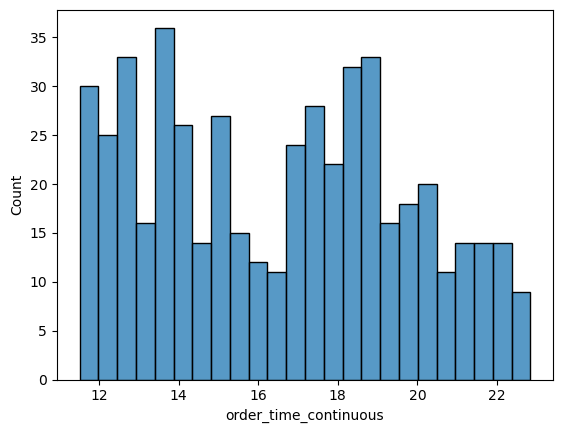

In [8]:
sns.histplot(pizza['order_time_continuous'], bins=24);

1. Plantear un modelo de mezcla finita (por ejemplo, mezcla de dos o m ́as normales)
y justificar la elecci ́on.

In [9]:
obs = pizza['order_time_continuous']

In [10]:
k = 2

with pm.Model() as model:
        w = pm.Dirichlet('w', a=np.ones(k))
        μ = pm.Normal('μ', mu=13, sigma=5, shape=k)
        σ = pm.HalfNormal('σ', sigma=5)

        x = pm.NormalMixture('x', w=w, mu=μ, sigma=σ, observed=obs)

        idata = pm.sample(random_seed=SEED, idata_kwargs={"log_likelihood":True}) 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 51 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


2. Analizar la identificabilidad del modelo y discutir posibles problemas de simetr ́ıa
entre componentes.


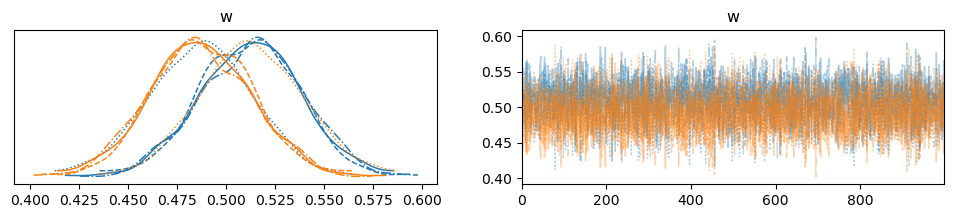

In [55]:
az.plot_trace(idata, var_names=['w']);

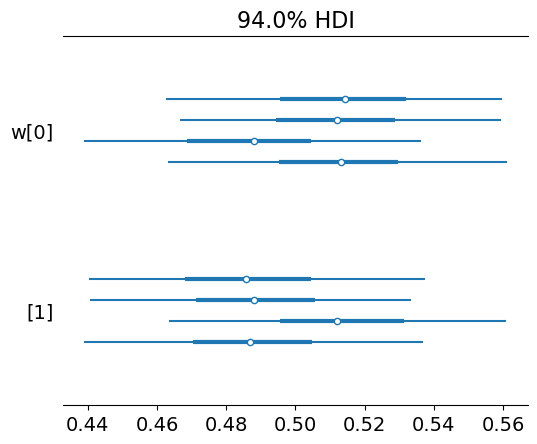

In [56]:
az.plot_forest(idata, var_names=['w']);

Para solucionar hay 2 opciones:
1. usar priors más informativos (es lo que hacemos)
2. ordenar

In [11]:
k = 2

with pm.Model() as model:
        w = pm.Dirichlet('w', a=np.ones(k))
        μ = pm.Normal('μ', mu=[18, 13], sigma=5, shape=k)
        σ = pm.HalfNormal('σ', sigma=5)

        x = pm.NormalMixture('x', w=w, mu=μ, sigma=σ, observed=obs)

        idata = pm.sample(random_seed=SEED, idata_kwargs={"log_likelihood":True}) 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 52 seconds.


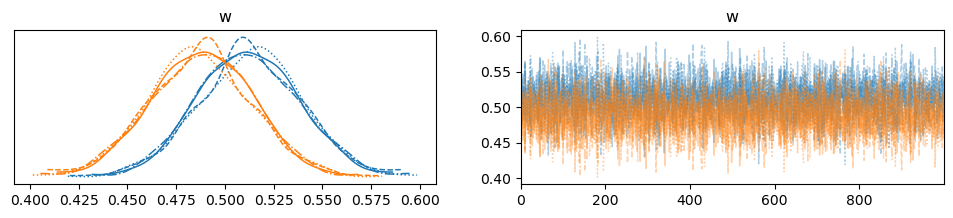

In [62]:
az.plot_trace(idata, var_names=['w']);

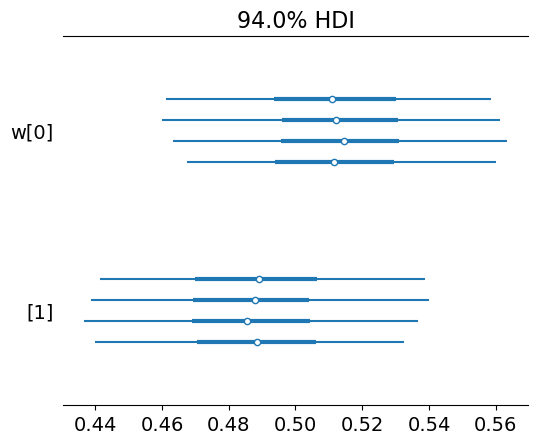

In [61]:
az.plot_forest(idata, var_names=['w']);

In [64]:
az.summary(idata, kind='diagnostics')

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
μ[0],0.002,0.002,4273.0,3382.0,1.0
μ[1],0.002,0.002,3364.0,2901.0,1.0
w[0],0.000,0.000,3706.0,3208.0,1.0
w[1],0.000,0.000,3706.0,3208.0,1.0
σ,0.001,0.001,4795.0,3336.0,1.0


In [12]:
with model:
    pm.sample_posterior_predictive(idata, random_seed=SEED, extend_inferencedata=True)

Sampling: [x]


Output()

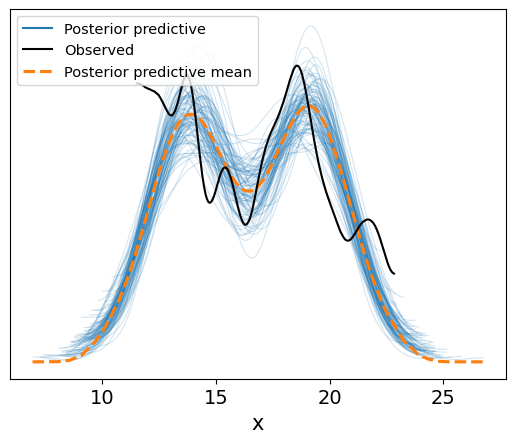

In [13]:
az.plot_ppc(idata, num_pp_samples=100);

Tenemos predicciones para horas en las que la pizzeria esta cerrada. Generalmente para estos casos se usan distribuciones circulares, pero es un embole. Vamos a usar una mezcla de normales truncadas en los horarios de la pizzeria.

In [34]:
k = 2

with pm.Model() as modelo_truncado:
    w = pm.Dirichlet('w', a=np.ones(k))
    μ = pm.TruncatedNormal('μ', mu=[13, 18], sigma=2, lower=11.0, upper=23.0, shape=k)

    σ = pm.HalfNormal('σ', sigma=3)

    comp_dists = [pm.TruncatedNormal.dist(mu=μ[i], sigma=σ, lower=11.0, upper=23.0) for i in range(k)]

    x = pm.Mixture('x', w=w, comp_dists=comp_dists, observed=obs)

    idata_truncado = pm.sample(random_seed=SEED, idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 57 seconds.


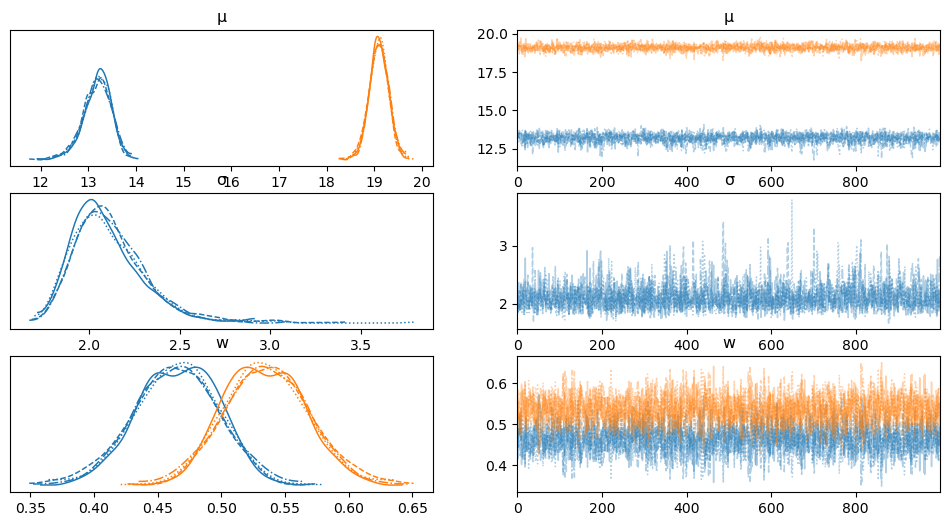

In [35]:
az.plot_trace(idata_truncado, var_names=['μ', 'σ', 'w']);

In [36]:
with modelo_truncado:
    pm.sample_posterior_predictive(idata_truncado, random_seed=SEED, extend_inferencedata=True)

Sampling: [x]


Output()

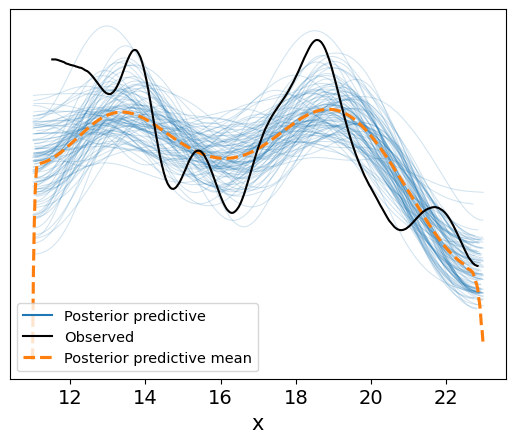

In [37]:
az.plot_ppc(idata_truncado, num_pp_samples=100);

3. Comparar distintos valores de K(n ́umero de componentes) y evaluar cu ́al describe
mejor los datos.

Mientras más K, más informativos deben ser los priors (menor $\sigma$)

In [45]:
Ks = [2, 3, 4, 5]

idatas = []
modelos = []

for k in Ks:
    with pm.Model() as modelo:
        w = pm.Dirichlet('w', a=np.ones(k))
        μ = pm.TruncatedNormal('μ', mu=np.quantile(obs, np.linspace(0.05, 0.95, k)), sigma=2/k, lower=11.0, upper=23.0, shape=k)

        σ = pm.HalfNormal('σ', sigma=4/k)

        comp_dists = [pm.TruncatedNormal.dist(mu=μ[i], sigma=σ, lower=11.0, upper=23.0) for i in range(k)]

        x = pm.Mixture('x', w=w, comp_dists=comp_dists, observed=obs)

        idata = pm.sample(target_accept=0.95, random_seed=SEED, idata_kwargs={"log_likelihood": True})

        idatas.append(idata)
        modelos.append(modelo)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 62 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 69 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 93 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, μ, σ]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 156 seconds.


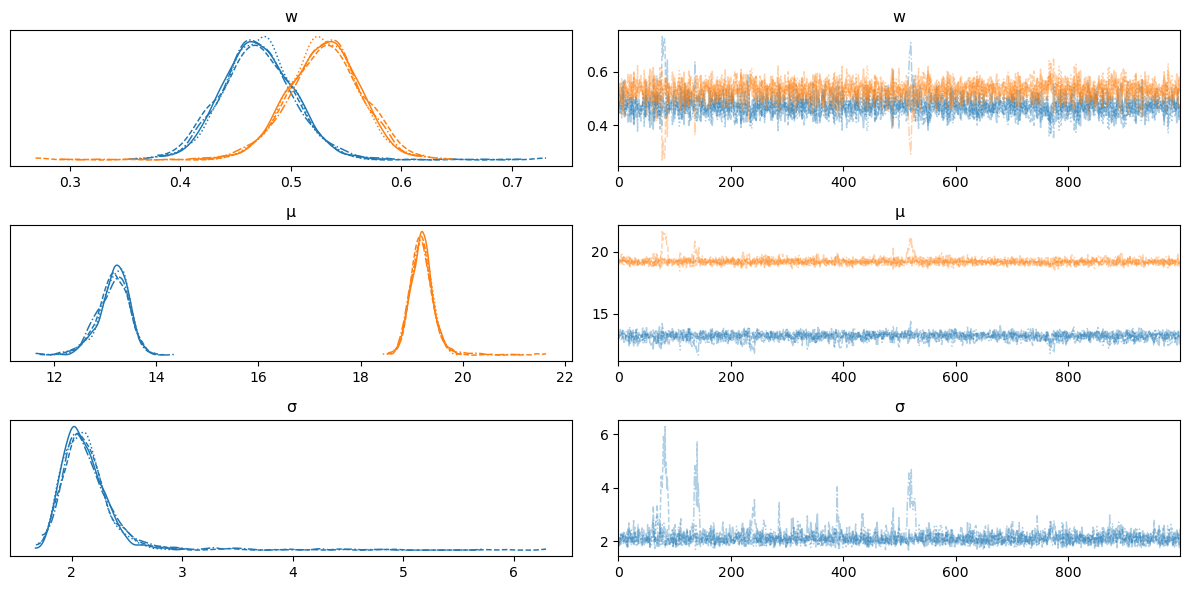

In [50]:
az.plot_trace(idatas[0])
plt.tight_layout();

La traza parece tener algún problema pero nada muy importante, el $\hat{R}$ y el ESS están dentro de lo aceptado.

In [51]:
az.summary(idatas[0], kind='diagnostics')

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w[0],0.001,0.002,1808.0,1269.0,1.0
w[1],0.001,0.002,1808.0,1269.0,1.0
μ[0],0.008,0.009,1614.0,1079.0,1.0
μ[1],0.009,0.025,1625.0,895.0,1.0
σ,0.015,0.050,1232.0,623.0,1.0


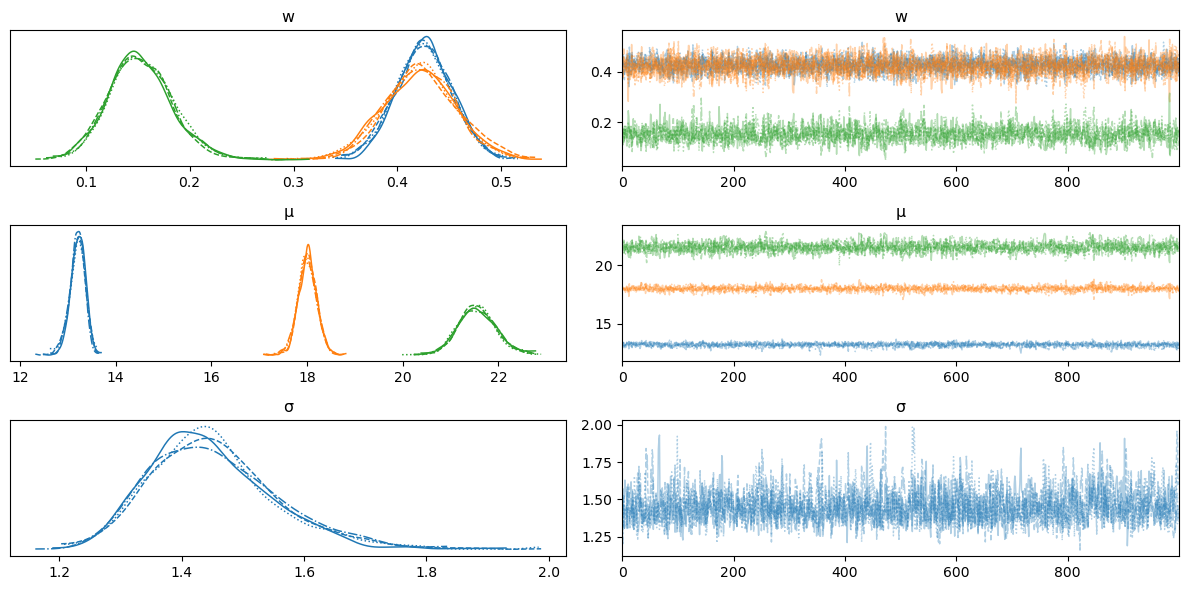

In [52]:
az.plot_trace(idatas[1])
plt.tight_layout();

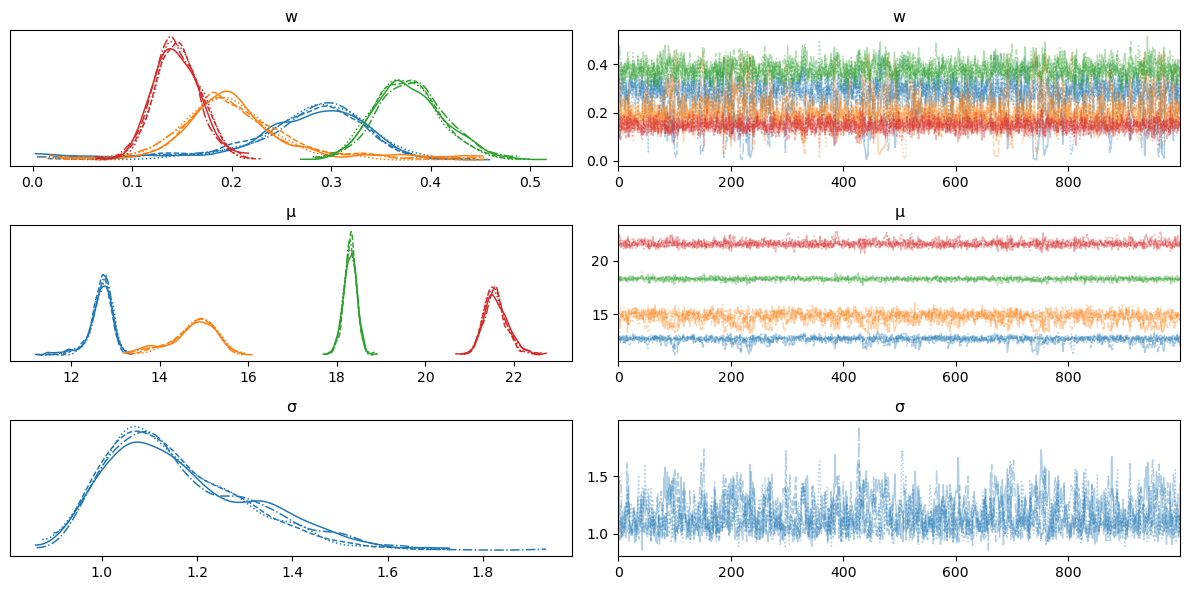

In [53]:
az.plot_trace(idatas[2])
plt.tight_layout();

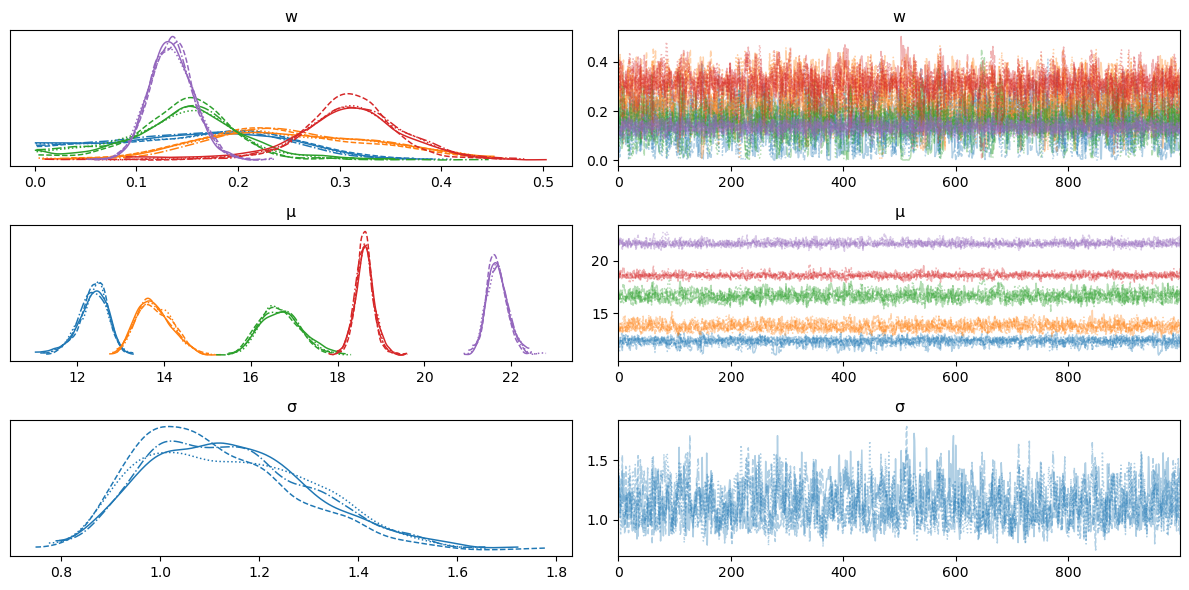

In [54]:
az.plot_trace(idatas[3])
plt.tight_layout();

In [55]:
df_comp = az.compare({f'k={k}': idata for k, idata in zip(Ks, idatas)})
df_comp

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
k=4,0,-1213.598352,7.065580,0.000000,1.000000e+00,6.990896,0.000000,False,log
k=5,1,-1214.528772,7.024213,0.930420,2.122746e-13,6.899582,1.293107,False,log
k=3,2,-1216.017702,5.418012,2.419351,1.305622e-13,6.708494,1.974748,False,log
k=2,3,-1223.830521,4.122759,10.232169,0.000000e+00,5.825269,4.101425,False,log


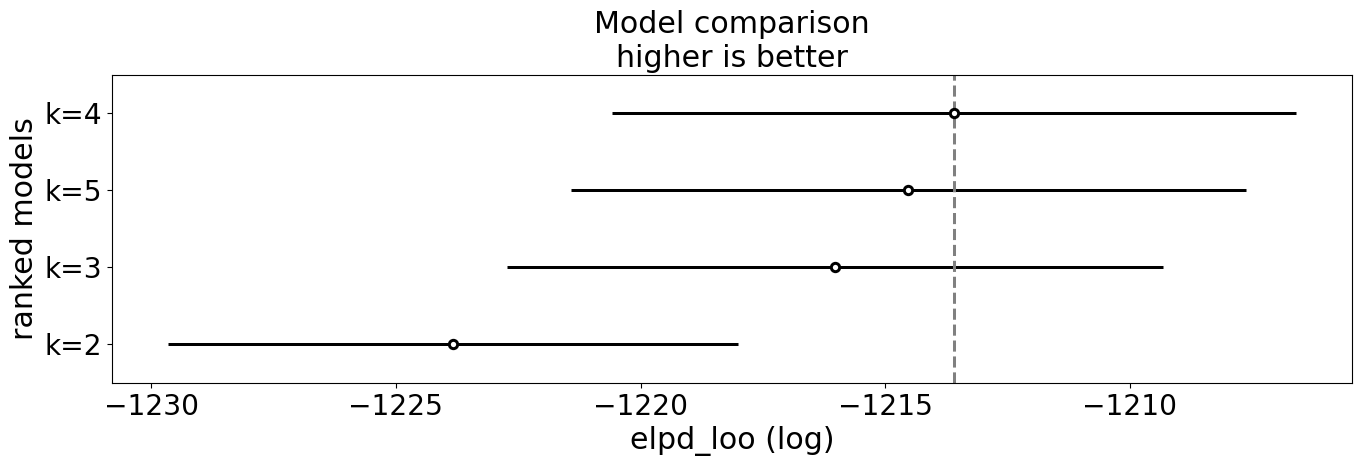

In [65]:
az.plot_compare(df_comp, figsize=(16, 4));

k=4 es que tiene mejor capacidad predictiva.  
k=3 es más simple y no se queda atrás en loo. 

In [66]:
idata_k2 = idatas[0]
idata_k3 = idatas[1]
idata_k4 = idatas[2]
idata_k5 = idatas[3]

In [67]:
modelo_k2 = modelos[0]
modelo_k3 = modelos[1]
modelo_k4 = modelos[2]
modelo_k5 = modelos[3]

In [68]:
with modelo_k2:
    pm.sample_posterior_predictive(idata_k2, random_seed=SEED, extend_inferencedata=True)

with modelo_k3:
    pm.sample_posterior_predictive(idata_k3, random_seed=SEED, extend_inferencedata=True)

with modelo_k4:
    pm.sample_posterior_predictive(idata_k4, random_seed=SEED, extend_inferencedata=True)

with modelo_k5:
    pm.sample_posterior_predictive(idata_k5, random_seed=SEED, extend_inferencedata=True)

Sampling: [x]


Output()

Sampling: [x]


Output()

Sampling: [x]


Output()

Sampling: [x]


Output()

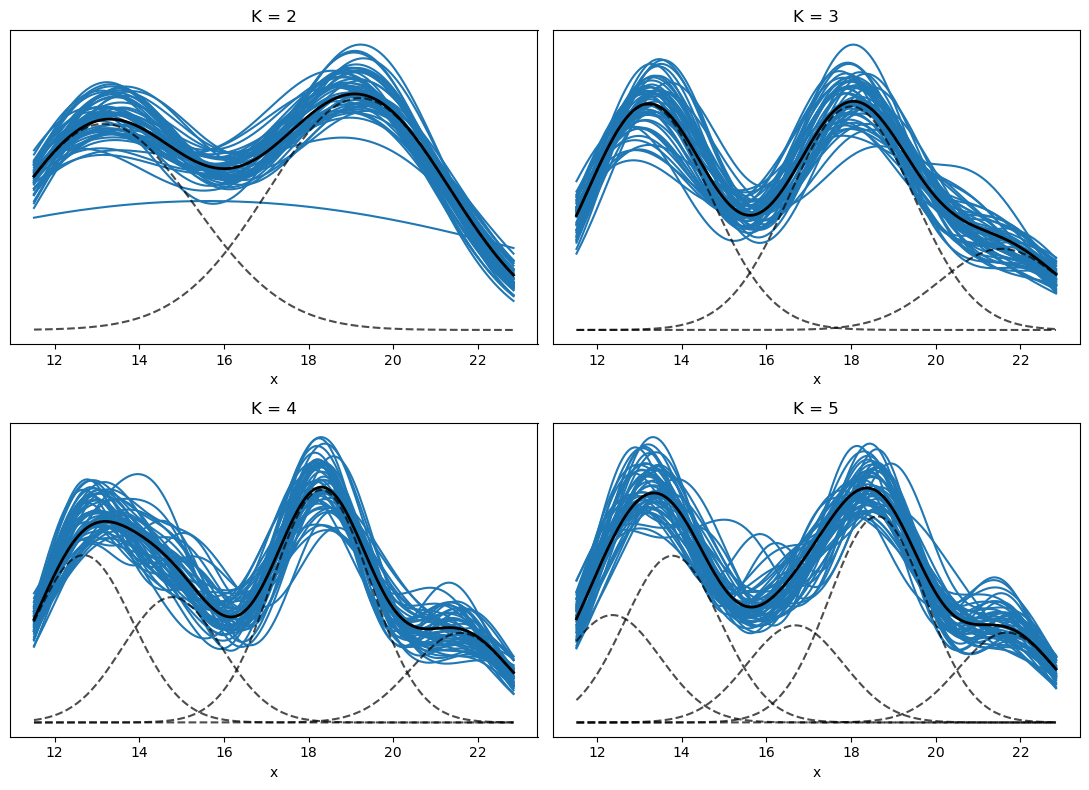

In [80]:
_, ax = plt.subplots(2, 2, figsize=(11, 8))
 
ax = np.ravel(ax)
x = np.linspace(obs.min(), obs.max(), 200)
for idx, idata_x in enumerate(idatas):
    posterior_x = idata_x.posterior.stack(samples=("chain", "draw"))
    x_ = np.array([x] * Ks[idx]).T

    for i_ in np.random.randint(0, posterior_x.samples.size, size=50):
        dist = pz.Normal(posterior_x['μ'][:,i_], posterior_x['σ'][i_])
        ax[idx].plot(x, np.sum(dist.pdf(x_) *  posterior_x['w'][:,i_].values, 1), 'C0')
 
    p_y = posterior_x['w'].mean("samples")
    dist = pz.Normal(posterior_x['μ'].mean("samples"), posterior_x['σ'].mean())
    ax[idx].plot(x, np.sum(dist.pdf(x_) * p_y.values, 1), 'k', lw=2)
    ax[idx].plot(x, dist.pdf(x_) * p_y.values, 'k--', alpha=0.7)
         
    ax[idx].set_title('K = {}'.format(Ks[idx]))
    ax[idx].set_yticks([])
    ax[idx].set_xlabel('x')

plt.tight_layout();

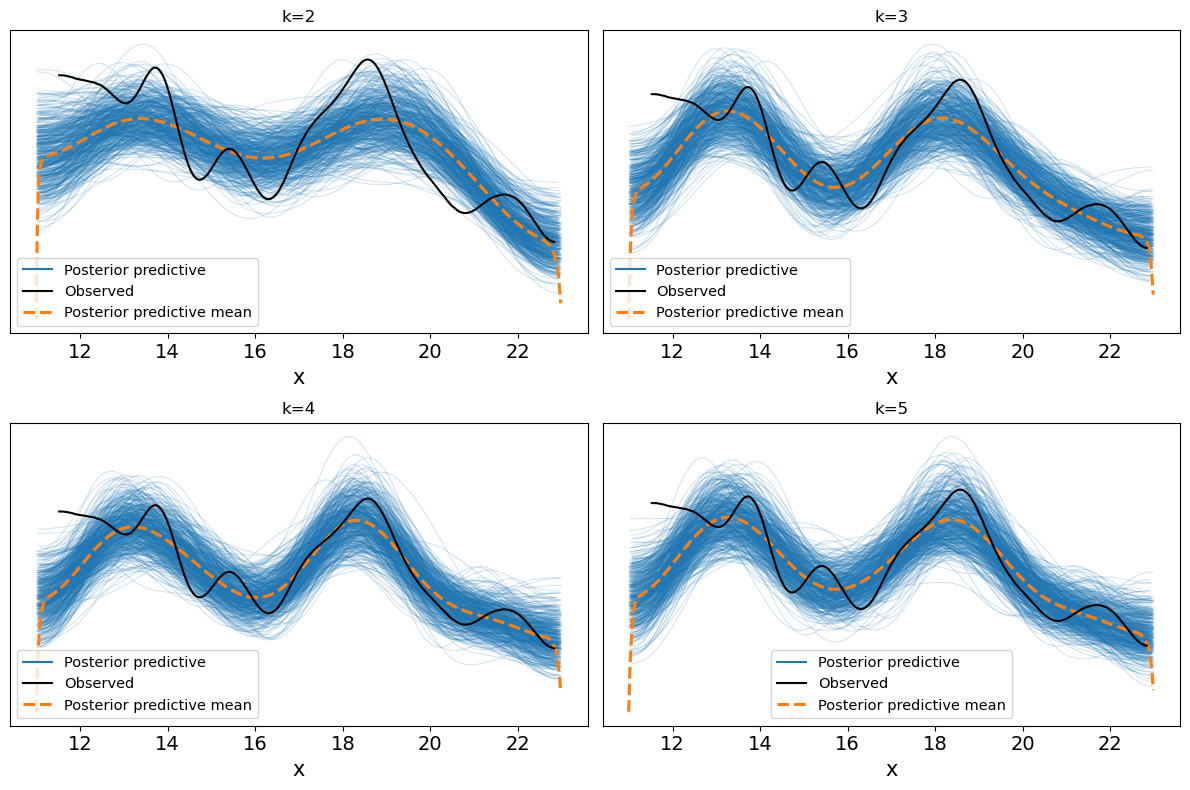

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

az.plot_ppc(idata_k2, ax=axes[0,0], num_pp_samples=500)
axes[0,0].set_title('k=2')

az.plot_ppc(idata_k3, ax=axes[0,1], num_pp_samples=500)
axes[0,1].set_title('k=3')

az.plot_ppc(idata_k4, ax=axes[1,0], num_pp_samples=500)
axes[1,0].set_title('k=4')

az.plot_ppc(idata_k5, ax=axes[1,1], num_pp_samples=500)
axes[1,1].set_title('k=5')

plt.tight_layout();

A todo esto, cuales son las horas pico?

según nuestro mejor modelo hay 4 grupos (4 horarios principales).

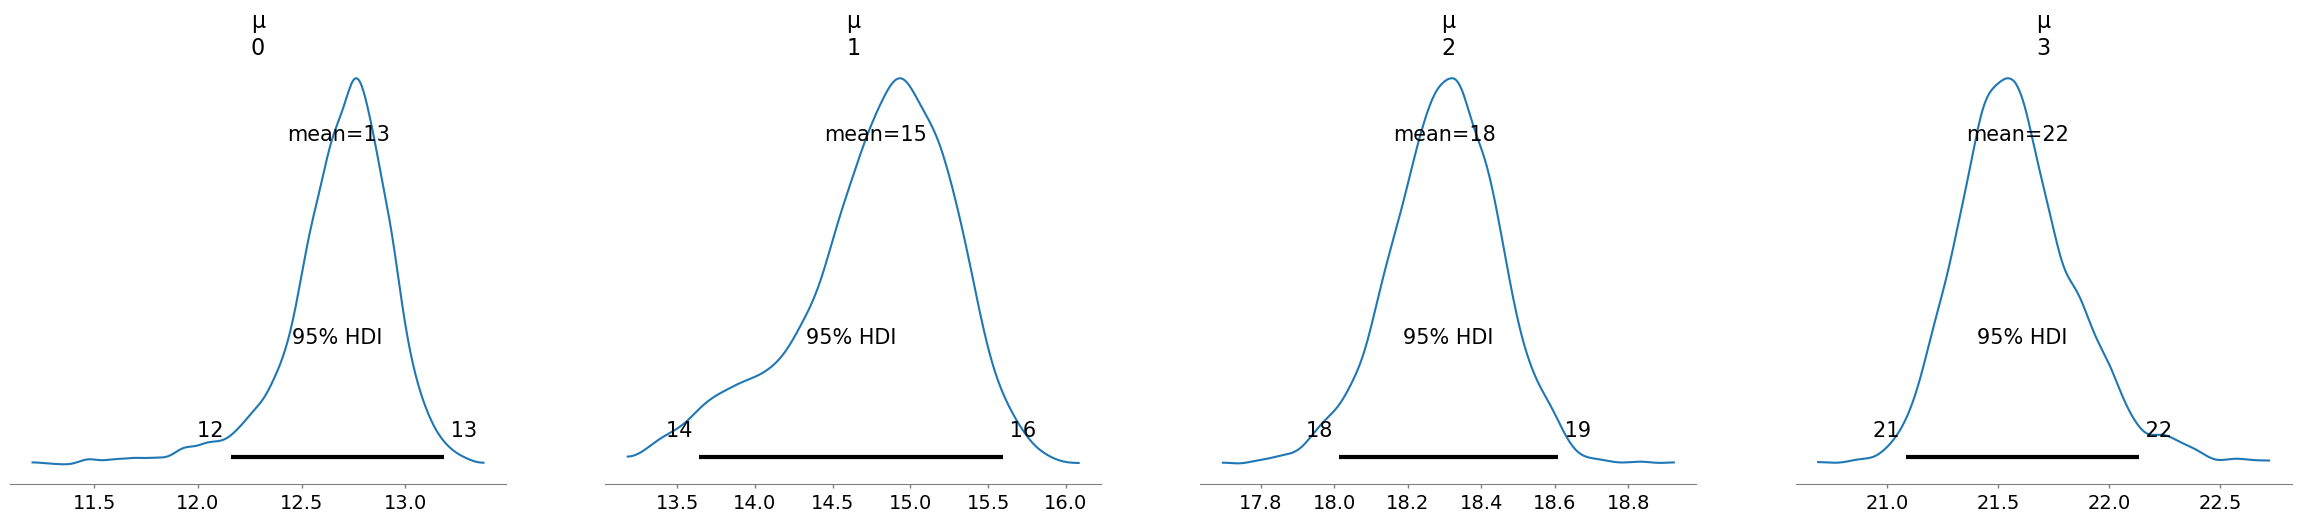

In [81]:
az.plot_posterior(idata_k4, var_names=['μ'], hdi_prob=0.95);

Las 13, 15, 18 y 22 hs son los horarios que le dan forma a nuestra data.  
Para saber cuales son horarios pico podemos ver los pesos

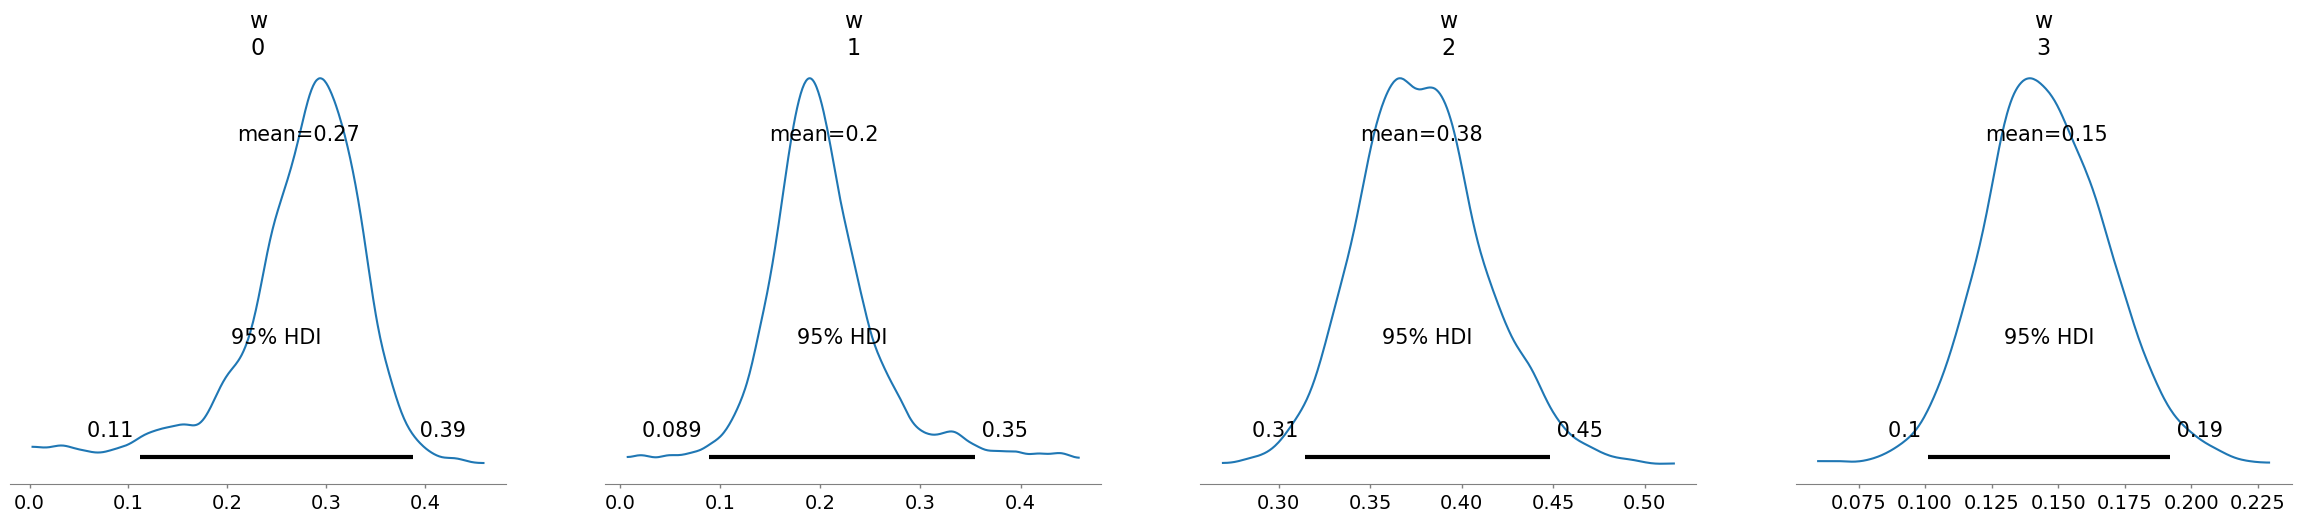

In [84]:
az.plot_posterior(idata_k4, var_names=['w'], hdi_prob=0.95);

Entiendo que esto nos dice que las horas más activas son alrededor de las 18, seguido por las 13, las 22 y las 15, en ese orden.